# pyTEM: 1-D TEM Forward Modelling

Welcome to **pyTEM**, an open-source Python package for 1-D layered-earth time-domain electromagnetic (TEM) modelling and inversion. This is the **first notebook** in the series and introduces the forward model: how an earth model is turned into a measured TEM signal. Later notebooks build on it to compute sensitivities (the Jacobian) and to recover resistivity models from data by inversion.

## What is TEM?

In a TEM survey, a steady current is driven through a transmitter loop laid on the ground and then switched off abruptly. The collapsing primary field induces eddy currents in the subsurface that diffuse downward and outward over time. The decaying secondary magnetic field they produce is recorded at a receiver as the voltage $\partial B_z / \partial t$, sampled at a sequence of *gate times* spanning several decades. Early gates sense the shallow subsurface and late gates sense progressively deeper structure, so the decay curve carries the imprint of the resistivity layering with depth.

## What PyTEM computes

This notebook computes the TEM step-off response $\partial B_z / \partial t$ for a 1-D horizontally layered, isotropic earth beneath a grounded loop source. Four loop configurations are supported:

| Function | Tx shape | Rx position |
|----------|----------|-------------|
| `fwd_circle_central` | Circular | Centre of loop |
| `fwd_circle_offset` | Circular | Radial offset |
| `fwd_square_central` | Square | Centre of loop |
| `fwd_square_offset` | Square | Arbitrary (x, y) |

The same calculation runs on three interchangeable compute backends (NumPy reference, Numba JIT on CPU, and CuPy on CUDA GPUs), selected automatically for speed without changing the result.

## Computation sequence

The forward model converts an earth model (layer thicknesses and resistivities) into the measured time-domain signal $\partial B_z / \partial t$ through three main steps:

1. **Reflection coefficient** $r_{TE}(\lambda, \omega)$: Wait's recursion (Ward & Hohmann, 1988)

   The layered earth responds differently to EM waves arriving at different angles (horizontal wavenumbers $\lambda$) and oscillating at different frequencies ($\omega$). The TE reflection coefficient encodes this full electromagnetic response in a single function. Wait's upward recursion computes it efficiently by starting from the bottom half-space (where it is zero, since there is no reflector below an infinite half-space) and propagating the reflection boundary condition upward through each layer interface in turn towards the air, where the final value gives $r_{TE}(\lambda, \omega)$, the surface reflection coefficient used in the Hankel integrals.

2. **Frequency-domain field** $H_z^{sec}(\omega)$: Hankel $J_1$ digital linear filter (Key, 2009)

   To obtain the actual secondary vertical magnetic field at the receiver, $r_{TE}$ must be integrated over all horizontal wavenumbers, weighted by the transmitter geometry (loop shape and size). This Hankel transform is replaced by a fast, accurate weighted sum using Key's digital linear filter (DLF) coefficients. The calculation is repeated at many frequencies so that a subsequent time-domain transform can be applied.

3. **Time-domain response** $\partial B_z / \partial t$: Fourier sine/cosine DLF (Key, 2009) or Euler-accelerated inverse Laplace transform (Abate & Whitt, 1995)

   TEM instruments record a transient in time, not a spectrum, so the final stage converts the frequency-domain field $H_z^{sec}(\omega)$ back to the measured time series. The exact transform depends on the transmitter signal convention, selected through the `signal` keyword: a sine transform (imaginary part) for **step-off** signals, and a cosine transform (real part) for **step-on** or **impulse** signals. The default method is a **Fourier sine/cosine DLF**, which evaluates this transform as a weighted sum using Key's filter coefficients, exactly as in step 2 but with the Bessel kernel replaced by $\sin$ or $\cos$. As a fully independent alternative, pyTEM also provides an **Euler-accelerated inverse Laplace transform** (Abate & Whitt, 1995), selected with `transform='euler'`. It is mathematically unrelated to the Fourier route: it evaluates the Bromwich inverse-Laplace integral in the complex $s$-plane and accelerates the resulting near-alternating series with precomputed Euler weights (orders 8, 11, 15, and 19; the default is 11). Because the two routes share no quadrature weights, their agreement to better than $0.05\%$ (shown in Notebook 2) is strong evidence that both are correct. Either way the integral becomes a fast, stable weighted sum over many decades of time.

## Running a forward model

The forward functions (`fwd_circle_central`, `fwd_circle_offset`, `fwd_square_central`, `fwd_square_offset`) wrap all three steps internally. You define the earth model, loop geometry, and gate times, then call a single function to obtain the complete time-gate response. The minimal workflow is:

```python
thicknesses   = [30, 100]         # two layer thicknesses [m]
resistivities = [100, 10, 300]    # three layer resistivities [Ohm.m]
times = np.logspace(-5, -2, 31)   # gate centre times [s]

dbdt = fwd_circle_central(thicknesses, resistivities, tx_radius=113.0, times=times)
```

To account for real systems where the receiver has a band-limited frequency response and the transmitter current does not switch off instantaneously, two optional corrections can be applied on top of the basic forward response:
- **Receiver filter** (`system_filter`): a `butterworth_filter` or `cascade_filter` callable that multiplies $H_z^{sec}(\omega)$ before the time transform to model the receiver's frequency-dependent gain. This is applied in the frequency domain, inside step 2.
- **Transmitter waveform** (`convolve_waveform`): convolves the step-off response with a piecewise-linear current waveform to account for a finite current ramp-off. This is applied in the time domain, after step 3, as a separate call.

## References
- Key (2009), *Geophysics* 74(2), F9–F20 — DLF filter coefficients
- Ward & Hohmann (1988), in Nabighian (ed.), *EM Methods in Applied Geophysics*, SEG — layered-earth theory, analytical solutions
- Abate & Whitt (1995), *INFORMS Journal on Computing* 7(1), 36–43 — Euler acceleration of the inverse Laplace transform

### Step 1: TE Reflection Coefficient - Wait's Recursion

In a layered earth, any plane wave can be decomposed into two polarisation modes:

- **TE (Transverse Electric):** the electric field is horizontal (parallel to the layer boundaries); the magnetic field has a vertical component. This is the mode excited by a horizontal loop (magnetic dipole) source and is therefore the relevant mode for TEM soundings.
- **TM (Transverse Magnetic):** the magnetic field is horizontal; the electric field has a vertical component. This mode is not excited by a vertical magnetic dipole and is therefore not needed for the loop configurations in this notebook.

For a thorough treatment of TE and TM modes in layered media see Hunziker, Thorbecke & Slob (2015), *The electromagnetic response in a layered vertical transverse isotropic medium: A new look at an old problem*, Applied Geophysics and Petrophysics.

The TE surface reflection coefficient $r_{TE}(\lambda, \omega)$ encodes the response of an $N$-layer earth. The vertical wavenumber in each layer is:

$$\Gamma_j = \sqrt{\lambda^2 + j\omega\mu_0\sigma_j}$$

The recursion starts from the bottom half-space ($\gamma_N = 0$) and propagates upward:

$$\psi_{j+1} = \frac{\Gamma_j - \Gamma_{j+1}}{\Gamma_j + \Gamma_{j+1}}, \qquad
\gamma_j = e^{-2\Gamma_j h_j}\,\frac{\gamma_{j+1} + \psi_{j+1}}{1 + \gamma_{j+1}\,\psi_{j+1}}$$


In [13]:
import numpy as np

def te_reflection_coeff(lam, omega, thicknesses, resistivities):
    """
    TE surface reflection coefficient via Wait's upward recursion.

    Parameters
    ----------
    lam           : (K,)   horizontal wavenumbers [1/m]
    omega         : float  angular frequency [rad/s]
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m] (may be complex for IP)

    Returns
    -------
    r_TE : (K,) complex128
    """
    n_lay = len(resistivities)
    sval = 1j * omega
    resistivities = np.asarray(resistivities, dtype=complex)

    sigma = 1.0 / resistivities
    Gamma = np.sqrt(lam[None, :]**2 + (sval * MU0 * sigma)[:, None])

    # Upward recursion from bottom half-space
    r = np.zeros(len(lam), dtype=complex)
    for j in range(n_lay - 2, -1, -1):
        psi = (Gamma[j] - Gamma[j + 1]) / (Gamma[j] + Gamma[j + 1])
        r = np.exp(-2.0 * Gamma[j] * thicknesses[j]) * (r + psi) / (1.0 + r * psi)

    # Air–earth interface
    psi_air = (lam - Gamma[0]) / (lam + Gamma[0])
    r_TE = (r + psi_air) / (1.0 + r * psi_air)
    return r_TE

### Step 2: Frequency-Domain Field via Hankel Transform (Key, 2009)

To convert the reflection coefficient $r_{TE}(\lambda, \omega)$ into the actual secondary magnetic field at the receiver, it must be integrated over all horizontal wavenumbers $\lambda$. This is a Hankel transform — an integral of the form

$$H_z^{sec}(\omega) = \int_0^\infty f(\lambda)\,J_\nu(\lambda r)\,d\lambda$$

where $J_\nu$ is a Bessel function of order $\nu$, $r$ is the source–receiver distance, and $f(\lambda)$ contains $r_{TE}$ weighted by the transmitter geometry. Two variants arise depending on the configuration:

- **$J_1$ transform** (central loop, circular offset): the loop source produces a $\lambda J_1(\lambda a)$ weighting, where $a$ is the loop radius.
- **$J_0$ transform** (square loop, VMD Green's function): the area integration over source elements uses a $\lambda^2 J_0(\lambda d)$ weighting, where $d$ is the distance from a source element to the receiver.

Computing these integrals directly is expensive because $J_\nu$ oscillates indefinitely. Key (2009) provides **digital linear filter (DLF)** coefficients that reduce the integral to a simple dot product:

$$\int_0^\infty f(\lambda)\,J_\nu(\lambda r)\,d\lambda \;\approx\; \frac{1}{r}\sum_{i=1}^{N} w_i\,f\!\left(\frac{b_i}{r}\right)$$

The filter base points $b_i$ are pre-computed logarithmically spaced nodes; dividing by $r$ maps them to the required $\lambda$ values. The weights $w_i$ are tabulated constants. This means the entire Hankel integral reduces to evaluating $f(\lambda)$ at $N$ points and taking a dot product with $w_i$ — just a few microseconds per frequency. The calculation is repeated at each of the $M$ Fourier filter frequencies to build the spectrum needed for step 3.


In [14]:
import numpy as np
from scipy.special import erf, j0  # j0: zeroth-order Bessel function
import matplotlib.pyplot as plt

MU0 = 4e-7 * np.pi  # vacuum permeability [H/m]

# ============================================================================
# Digital Filter Coefficients (Key, 2009) — CC-BY-4.0, Kerry Key
# ============================================================================

# --- Hankel J0 / J1 201-pt filter ---
_HANKEL_BASE_201 = np.array([
    6.11252761e-04, 6.58201133e-04, 7.08755459e-04, 7.63192702e-04, 8.21811096e-04, 8.84931781e-04, 9.52900564e-04, 1.02608981e-03, 1.10490049e-03, 1.18976437e-03, 1.28114637e-03, 1.37954713e-03, 1.48550574e-03, 1.59960269e-03, 1.72246306e-03, 1.85475995e-03, 1.99721813e-03, 2.15061808e-03, 2.31580018e-03, 2.49366940e-03, 2.68520018e-03, 2.89144182e-03, 3.11352423e-03, 3.35266408e-03,
    3.61017150e-03, 3.88745724e-03, 4.18604042e-03, 4.50755681e-03, 4.85376785e-03, 5.22657025e-03, 5.62800641e-03, 6.06027561e-03, 6.52574602e-03, 7.02696772e-03, 7.56668667e-03, 8.14785970e-03, 8.77367077e-03, 9.44754840e-03, 1.01731844e-02, 1.09545542e-02, 1.17959385e-02, 1.27019469e-02, 1.36775428e-02, 1.47280712e-02, 1.58592873e-02, 1.70773885e-02, 1.83890482e-02, 1.98014522e-02,
    2.13223385e-02, 2.29600392e-02, 2.47235265e-02, 2.66224616e-02, 2.86672478e-02, 3.08690875e-02, 3.32400435e-02, 3.57931051e-02, 3.85422591e-02, 4.15025669e-02, 4.46902465e-02, 4.81227616e-02, 5.18189172e-02, 5.57989627e-02, 6.00847027e-02, 6.46996168e-02, 6.96689877e-02, 7.50200401e-02, 8.07820897e-02, 8.69867040e-02, 9.36678748e-02, 1.00862205e-01, 1.08609109e-01, 1.16951028e-01,
    1.25933662e-01, 1.35606225e-01, 1.46021706e-01, 1.57237166e-01, 1.69314051e-01, 1.82318522e-01, 1.96321825e-01, 2.11400678e-01, 2.27637688e-01, 2.45121812e-01, 2.63948835e-01, 2.84221902e-01, 3.06052079e-01, 3.29558961e-01, 3.54871332e-01, 3.82127865e-01, 4.11477886e-01, 4.43082188e-01, 4.77113916e-01, 5.13759511e-01, 5.53219738e-01, 5.95710779e-01, 6.41465421e-01, 6.90734331e-01,
    7.43787428e-01, 8.00915364e-01, 8.62431115e-01, 9.28671694e-01, 1.00000000e+00, 1.07680681e+00, 1.15951290e+00, 1.24857138e+00, 1.34447016e+00, 1.44773461e+00, 1.55893049e+00, 1.67866696e+00, 1.80760000e+00, 1.94643598e+00, 2.09593551e+00, 2.25691763e+00, 2.43026426e+00, 2.61692509e+00, 2.81792275e+00, 3.03435839e+00, 3.26741777e+00, 3.51837769e+00, 3.78861304e+00, 4.07960431e+00,
    4.39294568e+00, 4.73035381e+00, 5.09367717e+00, 5.48490624e+00, 5.90618437e+00, 6.35981952e+00, 6.84829694e+00, 7.37429275e+00, 7.94068862e+00, 8.55058755e+00, 9.20733087e+00, 9.91451654e+00, 1.06760189e+01, 1.14960098e+01, 1.23789816e+01, 1.33297716e+01, 1.43535888e+01, 1.54560421e+01, 1.66431713e+01, 1.79214801e+01, 1.92979718e+01, 2.07801873e+01, 2.23762471e+01, 2.40948952e+01,
    2.59455471e+01, 2.79383417e+01, 3.00841965e+01, 3.23948675e+01, 3.48830138e+01, 3.75622667e+01, 4.04473044e+01, 4.35539326e+01, 4.68991710e+01, 5.05013465e+01, 5.43801936e+01, 5.85569626e+01, 6.30545358e+01, 6.78975533e+01, 7.31125475e+01, 7.87280887e+01, 8.47749417e+01, 9.12862341e+01, 9.82976382e+01, 1.05847566e+02, 1.13977379e+02, 1.22731618e+02, 1.32158241e+02, 1.42308893e+02,
    1.53239185e+02, 1.65008997e+02, 1.77682811e+02, 1.91330060e+02, 2.06025511e+02, 2.21849672e+02, 2.38889237e+02, 2.57237556e+02, 2.76995151e+02, 2.98270264e+02, 3.21179450e+02, 3.45848217e+02, 3.72411714e+02, 4.01015468e+02, 4.31816185e+02, 4.64982607e+02, 5.00696435e+02, 5.39153329e+02, 5.80563974e+02, 6.25155238e+02, 6.73171415e+02, 7.24875561e+02, 7.80550937e+02, 8.40502561e+02,
    9.05058878e+02, 9.74573559e+02, 1.04942744e+03, 1.13003061e+03, 1.21682465e+03, 1.31028507e+03, 1.41092388e+03, 1.51929243e+03, 1.63598443e+03])

_HANKEL_J0_201 = np.array([
    1.10470282e-01, -3.00286017e-01, 0.00000000e+00, 9.30461200e-01, -1.23798946e+00, 0.00000000e+00, 1.52278250e+00, -1.48126221e+00, 0.00000000e+00, 1.20093868e+00, -1.04235628e+00, 0.00000000e+00, 8.18648215e-01, -7.83797944e-01, 0.00000000e+00, 1.07208794e+00, -2.01797348e+00, 2.63855191e+00, -2.91697381e+00, 2.93254772e+00, -2.78203018e+00, 2.54863429e+00, -2.28613254e+00, 2.02866803e+00,
    -1.79046655e+00, 1.57977821e+00, -1.39510079e+00, 1.23689978e+00, -1.09963335e+00, 9.82918061e-01, -8.80812750e-01, 7.93941732e-01, -7.16639998e-01, 6.50805245e-01, -5.90908776e-01, 5.40034683e-01, -4.92506229e-01, 4.52501283e-01, -4.13928215e-01, 3.82030383e-01, -3.50069492e-01, 3.24390747e-01, -2.97399101e-01, 2.76631789e-01, -2.53431563e-01, 2.36661771e-01, -2.16387521e-01, 2.02971642e-01,
    -1.84966378e-01, 1.74447028e-01, -1.58190179e-01, 1.50238638e-01, -1.35295617e-01, 1.29673244e-01, -1.15661986e-01, 1.12198183e-01, -9.87703710e-02, 9.73530775e-02, -8.41832455e-02, 8.47534796e-02, -7.15282980e-02, 7.40748091e-02, -6.04833687e-02, 6.50416260e-02, -5.07707453e-02, 5.74270624e-02, -4.21580485e-02, 5.10527683e-02, -3.44540282e-02, 4.57813906e-02, -2.74984240e-02, 4.15073432e-02,
    -2.11544963e-02, 3.81522446e-02, -1.53050072e-02, 3.56600696e-02, -9.84457209e-03, 3.39873559e-02, -4.66963434e-03, 3.30950575e-02, 3.24877506e-04, 3.29486029e-02, 5.24045127e-03, 3.35219193e-02, 1.01683927e-02, 3.47974801e-02, 1.51864069e-02, 3.67598908e-02, 2.03562310e-02, 3.93853729e-02, 2.57172055e-02, 4.26287903e-02, 3.12726505e-02, 4.64058662e-02, 3.69678931e-02, 5.05666415e-02,
    4.26573623e-02, 5.48568154e-02, 4.80569737e-02, 5.88632673e-02, 5.26793424e-02, 6.19408175e-02, 5.57526367e-02, 6.31234831e-02, 5.61317121e-02, 6.10387706e-02, 5.22307339e-02, 5.38734075e-02, 4.20500396e-02, 3.94953729e-02, 2.34446490e-02, 1.59297590e-02, -5.11245496e-03, -1.75042476e-02, -4.29302858e-02, -5.80653684e-02, -8.44383769e-02, -9.65164199e-02, -1.16035356e-01, -1.14571615e-01,
    -1.15274691e-01, -8.75311516e-02, -5.91736760e-02, -6.66037840e-04, 4.96649448e-02, 1.15720636e-01, 1.44896661e-01, 1.58899833e-01, 1.03159021e-01, 2.38946574e-02, -1.00760080e-01, -1.70108168e-01, -1.80659634e-01, -5.04422081e-02, 1.06755883e-01, 2.24384321e-01, 1.12486119e-01, -1.06075003e-01, -2.49468958e-01, -2.53256391e-02, 2.31309316e-01, 1.26504152e-01, -2.71689556e-01, -5.74167330e-02,
    2.82835580e-01, -1.15152918e-01, -1.89523821e-01, 3.49898182e-01, -3.28359449e-01, 2.22868994e-01, -1.19188270e-01, 4.91413686e-02, -1.08504633e-02, -6.98967317e-03, 1.39622510e-02, -1.58324765e-02, 1.55379889e-02, -1.44353414e-02, 1.31093449e-02, -1.17956256e-02, 1.05790917e-02, -9.48212916e-03, 8.50263635e-03, -7.63007614e-03, 6.85204315e-03, -6.15676104e-03, 5.53384941e-03, -4.97438301e-03,
    4.47069975e-03, -4.01616187e-03, 3.60495526e-03, -3.23195186e-03, 2.89263019e-03, -2.58303465e-03, 2.29975097e-03, -2.03987984e-03, 1.80100002e-03, -1.58112178e-03, 1.37863790e-03, -1.19228146e-03, 1.02109638e-03, -8.64416954e-04, 7.21843897e-04, -5.93200632e-04, 4.78459656e-04, -3.77640637e-04, 2.90693749e-04, -2.17388097e-04, 1.57224702e-04, -1.09388048e-04, 7.27427883e-05, -4.58750858e-05,
    2.71728425e-05, -1.49356966e-05, 7.50207244e-06, -3.37498001e-06, 1.32302857e-06, -4.34281335e-07, 1.12052939e-07, -2.02367922e-08, 1.92313395e-09])

_HANKEL_J1_201 = np.array([
    1.28963393e-05, -4.69285296e-05, 5.71240750e-05, 0.00000000e+00, -5.40189836e-05, 0.00000000e+00, 1.16381361e-04, -1.34158516e-04, 0.00000000e+00, 1.56352988e-04, -1.70193229e-04, 0.00000000e+00, 2.68521272e-04, -5.14862339e-04, 6.65351998e-04, -7.07223226e-04, 6.68404776e-04, -5.84796489e-04, 4.87702305e-04, -3.93931347e-04, 3.13634518e-04, -2.47006406e-04, 1.95399790e-04, -1.53960230e-04,
    1.23452983e-04, -9.81700811e-05, 8.05880436e-05, -6.45145998e-05, 5.45643043e-05, -4.34441904e-05, 3.81552305e-05, -2.94939366e-05, 2.73218718e-05, -1.95984297e-05, 1.98291173e-05, -1.20090479e-05, 1.44325161e-05, -5.68376186e-06, 1.04359456e-05, 4.51324023e-08, 7.45760932e-06, 5.65321675e-06, 5.30868840e-06, 1.15279657e-05, 3.93296160e-06, 1.80335284e-05, 3.38068357e-06, 2.55571603e-05,
    3.80372918e-06, 3.45489549e-05, 5.46613982e-06, 4.55623477e-05, 8.76810108e-06, 5.93009738e-05, 1.42841630e-05, 7.66767262e-05, 2.28186604e-05, 9.88843653e-05, 3.54828887e-05, 1.27499541e-04, 5.38004178e-05, 1.64609007e-04, 7.98495642e-05, 2.12984280e-04, 1.16455463e-04, 2.76313393e-04, 1.67448539e-04, 3.59510011e-04, 2.38011828e-04, 4.69125342e-04, 3.35146366e-04, 6.13897095e-04,
    4.68291916e-04, 8.05480570e-04, 6.50151999e-04, 1.05941791e-03, 8.97788165e-04, 1.39641449e-03, 1.23406477e-03, 1.84400910e-03, 1.68953833e-03, 2.43874427e-03, 2.30489552e-03, 3.22895249e-03, 3.13404918e-03, 4.27826046e-03, 4.24798136e-03, 5.66986413e-03, 5.73934169e-03, 7.51150088e-03, 7.72761477e-03, 9.94076845e-03, 1.03642681e-02, 1.31298792e-02, 1.38365214e-02, 1.72878829e-02,
    1.83669592e-02, 2.26565144e-02, 2.42037207e-02, 2.94926237e-02, 3.15919163e-02, 3.80249985e-02, 4.07106539e-02, 4.83658887e-02, 5.15515043e-02, 6.03483557e-02, 6.37053082e-02, 7.32537479e-02, 7.60224604e-02, 8.54018288e-02, 8.61375680e-02, 9.36304521e-02, 8.99478055e-02, 9.28543835e-02, 8.13853817e-02, 7.62570142e-02, 5.33184028e-02, 3.72841064e-02, 1.08891830e-03, -2.48218556e-02,
    -6.96698504e-02, -9.50837044e-02, -1.32045780e-01, -1.33318891e-01, -1.34567983e-01, -8.40360551e-02, -3.27015331e-02, 6.37470098e-02, 1.24372003e-01, 1.81896771e-01, 1.37574065e-01, 5.81187330e-02, -1.04308776e-01, -1.81559582e-01, -1.81991713e-01, 1.63140269e-02, 1.75237563e-01, 2.15230895e-01, -6.13583473e-02, -2.26001273e-01, -1.05881883e-01, 2.75172033e-01, 7.28207844e-02, -2.45390420e-01,
    -2.98155294e-02, 3.29532116e-01, -3.39568876e-01, 1.43734776e-01, 5.56913733e-02, -1.61897535e-01, 1.84088162e-01, -1.63847565e-01, 1.32309898e-01, -1.03584431e-01, 8.13282332e-02, -6.50210853e-02, 5.31663246e-02, -4.44148369e-02, 3.77901726e-02, -3.26363160e-02, 2.85210434e-02, -2.51578544e-02, 2.23533948e-02, -1.99741605e-02, 1.79257404e-02, -1.61398062e-02, 1.45658280e-02, -1.31656927e-02,
    1.19101328e-02, -1.07763105e-02, 9.74615154e-03, -8.80517986e-03, 7.94168889e-03, -7.14614581e-03, 6.41075936e-03, -5.72916501e-03, 5.09619569e-03, -4.50771436e-03, 3.96049005e-03, -3.45210171e-03, 2.98085604e-03, -2.54570655e-03, 2.14616248e-03, -1.78217715e-03, 1.45400775e-03, -1.16204137e-03, 9.06587821e-04, -6.87647380e-04, 5.04671834e-04, -3.56348912e-04, 2.40450174e-04, -1.53786572e-04,
    9.23083411e-05, -5.13625291e-05, 2.60831821e-05, -1.18449968e-05, 4.67858772e-06, -1.54406422e-06, 3.99592180e-07, -7.21941602e-08, 6.84486411e-09])

HANKEL_FILTERS = {
    'key_201': (_HANKEL_BASE_201, _HANKEL_J0_201, _HANKEL_J1_201),

}

print(f"  Hankel filters   : {list(HANKEL_FILTERS.keys())}")

  Hankel filters   : ['key_201']


### Step 3: Time-Domain Response via Fourier Transform (Key, 2009)

After step 2 we have $H_z^{sec}(\omega)$ at many frequencies. TEM data are recorded in the time domain, so the final step is a Fourier transform from $\omega$ to $t$. The exact transform depends on the transmitter waveform:

**Step-off** (`signal = -1`, standard TEM): the transmitted current is steady, then cut instantaneously at $t = 0$. The earth's response decays freely afterwards. The relevant transform is the **Fourier sine transform** of the imaginary part of $H_z^{sec}$:

$$\frac{\partial B_z}{\partial t}(t) = \frac{2\mu_0 I}{\pi} \int_0^\infty \mathrm{Im}[H_z^{sec}(\omega)]\,\sin(\omega t)\,d\omega$$

**Impulse** (`signal = 0`): a $\delta$-function current pulse. This is the time derivative of the step-on response and uses the **Fourier cosine transform** of the real part instead:

$$\frac{\partial B_z}{\partial t}(t) = \frac{2\mu_0 I}{\pi} \int_0^\infty \mathrm{Re}[H_z^{sec}(\omega)]\,\cos(\omega t)\,d\omega$$

As in step 2, the DLF method (Key, 2009) replaces the oscillatory integral with a weighted sum. For the sine transform evaluated at gate time $t$:

$$\int_0^\infty F(\omega)\,\sin(\omega t)\,d\omega \;\approx\; \frac{1}{t}\sum_{m=1}^{M} w_m\,F\!\left(\frac{b_m}{t}\right)$$
The filter base points $b_m / t$ give the frequencies at which $H_z^{sec}(\omega)$ is needed — which is why step 2 must be run at each of those frequencies. The final dot product converts the frequency-domain spectrum into a single time-gate value $\partial B_z / \partial t$ at time $t$, and the process is repeated for every gate.


In [15]:
# --- Key (2012) 101-pt Fourier sine / cosine filter ---
_FOURIER_BASE_101 = np.array([
    2.08619195e-04, 2.47153736e-04, 2.92806083e-04, 3.46890982e-04, 4.10966030e-04, 4.86876529e-04, 5.76808636e-04, 6.83352313e-04, 8.09575922e-04, 9.59114591e-04, 1.13627490e-03, 1.34615890e-03, 1.59481107e-03, 1.88939237e-03, 2.23838647e-03, 2.65184408e-03, 3.14167243e-03, 3.72197812e-03, 4.40947343e-03, 5.22395762e-03,
    6.18888709e-03, 7.33205095e-03, 8.68637129e-03, 1.02908513e-02, 1.21916986e-02, 1.44436559e-02, 1.71115775e-02, 2.02722971e-02, 2.40168407e-02, 2.84530477e-02, 3.37086769e-02, 3.99350857e-02, 4.73115891e-02, 5.60506238e-02, 6.64038661e-02, 7.86694800e-02, 9.32007043e-02, 1.10416025e-01, 1.30811228e-01, 1.54973677e-01,
    1.83599229e-01, 2.17512274e-01, 2.57689476e-01, 3.05287904e-01, 3.61678349e-01, 4.28484806e-01, 5.07631240e-01, 6.01396998e-01, 7.12482449e-01, 8.44086754e-01, 1.00000000e+00, 1.18471235e+00, 1.40354335e+00, 1.66279513e+00, 1.96993392e+00, 2.33380504e+00, 2.76488765e+00, 3.27559653e+00, 3.88063966e+00, 4.59744172e+00,
    5.44664597e+00, 6.45270872e+00, 7.64460370e+00, 9.05665639e+00, 1.07295326e+01, 1.27114098e+01, 1.50593641e+01, 1.78410146e+01, 2.11364703e+01, 2.50406374e+01, 2.96659523e+01, 3.51456199e+01, 4.16374499e+01, 4.93284010e+01, 5.84399657e+01, 6.92345489e+01, 8.20230250e+01, 9.71736904e+01, 1.15122871e+02, 1.36387487e+02,
    1.61579939e+02, 1.91425749e+02, 2.26784448e+02, 2.68674336e+02, 3.18301803e+02, 3.77096077e+02, 4.46750378e+02, 5.29270689e+02, 6.27033520e+02, 7.42854353e+02, 8.80068724e+02, 1.04262828e+03, 1.23521460e+03, 1.46337399e+03, 1.73367723e+03, 2.05390882e+03, 2.43329114e+03, 2.88275006e+03, 3.41522959e+03, 4.04606466e+03,
    4.79342277e+03])

_FOURIER_SIN_101 = np.array([
    7.60403176e-07, -3.58553920e-06, 9.07861507e-06, -1.58261778e-05, 2.16670951e-05, -2.46395964e-05, 2.44088488e-05, -2.08200218e-05, 1.50670891e-05, -7.00507695e-06, -1.79585017e-06, 1.26033329e-05, -2.31846471e-05, 3.66492432e-05, -4.89253709e-05, 6.63037641e-05, -8.07432948e-05, 1.04508954e-04, -1.21592860e-04, 1.55847915e-04,
    -1.75451242e-04, 2.27009881e-04, -2.47343884e-04, 3.27832480e-04, -3.43328654e-04, 4.73172613e-04, -4.70069095e-04, 6.86179380e-04, -6.33414027e-04, 1.00400191e-03, -8.34879431e-04, 1.48793781e-03, -1.06363800e-03, 2.24207538e-03, -1.27901298e-03, 3.44822476e-03, -1.37377920e-03, 5.43159276e-03, -1.09987979e-03, 8.78414279e-03,
    7.83193932e-05, 1.45952084e-02, 3.26594594e-03, 2.48725125e-02, 1.06501790e-02, 4.32596417e-02, 2.63223162e-02, 7.60482703e-02, 5.71700572e-02, 1.32742902e-01, 1.12020916e-01, 2.22335357e-01, 1.91494014e-01, 3.31818544e-01, 2.46832732e-01, 3.58307438e-01, 8.60481247e-02, 2.90880091e-02, -5.67040642e-01, -6.24433464e-01,
    -8.67499649e-01, 4.08849114e-01, 9.86501865e-01, 9.13207919e-01, -2.23499607e+00, 9.82862636e-01, 5.52908444e-01, -1.09358161e+00, 9.93966343e-01, -7.50770305e-01, 5.49883816e-01, -4.11318755e-01, 3.17205141e-01, -2.51054332e-01, 2.02524025e-01, -1.65580133e-01, 1.36639964e-01, -1.13477274e-01, 9.46532224e-02, -7.91788380e-02,
    6.63522040e-02, -5.56563958e-02, 4.66922131e-02, -3.91517021e-02, 3.27863331e-02, -2.73942008e-02, 2.28116909e-02, -1.89007735e-02, 1.55488551e-02, -1.26625271e-02, 1.01646528e-02, -7.99647428e-03, 6.11362607e-03, -4.48885579e-03, 3.11327253e-03, -1.98974633e-03, 1.12993984e-03, -5.42182790e-04, 2.04505251e-04, -5.35411730e-05,
    7.23207675e-06])

_FOURIER_COS_101 = np.array([
    2.86728644e-02, -1.54498029e-01, 4.29250409e-01, -8.24969715e-01, 1.24783592e+00, -1.59926742e+00, 1.82431317e+00, -1.91453963e+00, 1.89348096e+00, -1.79370550e+00, 1.64830783e+00, -1.48081551e+00, 1.31013253e+00, -1.14491528e+00, 9.93435526e-01, -8.55532346e-01, 7.35198282e-01, -6.27966525e-01, 5.37388622e-01, -4.56514648e-01,
    3.90454366e-01, -3.29993497e-01, 2.83054743e-01, -2.37516380e-01, 2.05294324e-01, -1.70125537e-01, 1.49406696e-01, -1.20913795e-01, 1.09586988e-01, -8.46915525e-02, 8.16195167e-02, -5.75802673e-02, 6.25180186e-02, -3.66511051e-02, 5.02370727e-02, -1.96322187e-02, 4.34591015e-02, -4.67945364e-03, 4.14414268e-02, 9.79397475e-03,
    4.38921514e-02, 2.52108916e-02, 5.08088286e-02, 4.27662338e-02, 6.21175125e-02, 6.29627306e-02, 7.66965187e-02, 8.41045399e-02, 8.97774952e-02, 9.82726968e-02, 8.66782323e-02, 8.23439902e-02, 3.08695470e-02, -1.49099491e-02, -1.43297517e-01, -2.56921971e-01, -4.55641095e-01, -5.26429664e-01, -5.14601043e-01, -5.55026917e-02,
    5.78344820e-01, 1.12560642e+00, 2.13833400e-01, -1.36975586e+00, -5.40940535e-01, 2.16766249e+00, -1.94268416e+00, 1.05458705e+00, -4.19634907e-01, 1.23727918e-01, -1.24846791e-02, -2.37886749e-02, 3.31148782e-02, -3.32225971e-02, 3.03583525e-02, -2.67368131e-02, 2.31506371e-02, -1.98714051e-02, 1.69728472e-02, -1.44524971e-02,
    1.22793217e-02, -1.04138134e-02, 8.81582620e-03, -7.44787694e-03, 6.27643574e-03, -5.27190667e-03, 4.40865129e-03, -3.66461300e-03, 3.02096405e-03, -2.46200105e-03, 1.97487755e-03, -1.54967669e-03, 1.17952981e-03, -8.60587178e-04, 5.92029779e-04, -3.75259867e-04, 2.11955956e-04, -1.01500605e-04, 3.81581205e-05, -9.86333102e-06,
    1.29364033e-06])


FOURIER_FILTERS = {

    'key_101': (_FOURIER_BASE_101, _FOURIER_SIN_101, _FOURIER_COS_101),
}

print(f"  Fourier filters  : {list(FOURIER_FILTERS.keys())}")

  Fourier filters  : ['key_101']


### Step 3 (alternative): Time-Domain Response via the Euler-Stehfest Inverse Laplace Transform

The Fourier sine/cosine DLF above is the standard route from frequency to time. pyTEM ships a second, fully independent transform that works in the **Laplace** domain instead of the Fourier domain, selected with `transform='euler'`.

The step-off response can be written as an inverse Laplace transform,

$$ f(t) = \frac{1}{2\pi i}\int_{c-i\infty}^{c+i\infty} F(s)\, e^{st}\, ds, $$

where $F(s)$ is the Laplace-domain kernel built from the same recursive reflection coefficients, now evaluated at complex argument. Approximating this Bromwich integral numerically is the job of the **Euler-Stehfest** family of algorithms. pyTEM uses the Euler acceleration of Abate & Whitt (1995): the integral along the vertical line $\mathrm{Re}(s) = A/(2t)$ is discretised as an alternating series

$$ f(t) \approx \frac{e^{A/2}}{t}\left[ \tfrac{1}{2}\,\mathrm{Re}\,F\!\left(\tfrac{A}{2t}\right) + \sum_{k=1}^{2N} (-1)^k\,\mathrm{Re}\,F\!\left(\tfrac{A + 2\pi i k}{2t}\right) \right], $$

and Euler (binomial) summation is applied to the slowly converging alternating tail to accelerate convergence. Each gate $t$ therefore samples the kernel at $2N+1$ **complex** frequencies $s = (A + 2\pi i k)/(2t)$. In `pytem.euler`, `euler_invert(F, t, N, A)` implements exactly this, with the precomputed binomial weights stored in `EULER_PARAMS`.

**Why keep both transforms?**

- **Fourier DLF** (`transform='dlf'`) is fast, well tested, and the default. Its filter base points fix the *real* frequencies at which the kernel is sampled.
- **Euler-Stehfest** (`transform='euler'`) samples the kernel at *complex* frequencies and is a completely independent route to the same answer. Agreement between the two transforms is strong evidence that the forward code is correct, and the Laplace approach can be more robust at the very early and very late gates where the oscillatory Fourier integrand is hardest to sample.

Both transforms are exercised against the analytical solution in the validation section below; in practice they agree to well within measurement noise.


### Forward Models

A set of shared helper utilities is defined here before the individual forward models. These handle filter coefficient look-up, receiver scaling, signal-convention scaling, and the frequency-to-time DLF transform (`_freq_to_time`) that sits at the core of all four models.


In [ ]:
def _rx_scale(rx_area=1.0, rx_turns=1):
    """Receiver effective-area factor: N * A."""
    return float(rx_area) * float(rx_turns)

def _resolve_filters(hankel_filter, fourier_filter):
    """Look up DLF coefficient arrays by registry key."""
    h_base, h_j0, h_j1 = HANKEL_FILTERS[hankel_filter]
    f_base, f_sin, f_cos = FOURIER_FILTERS[fourier_filter]
    return h_base, h_j0, h_j1, f_base, f_sin, f_cos

def _apply_signal_scaling(dbdt, current, signal, quadrant_factor=1.0):
    """Apply current amplitude and step-off / step-on sign convention."""
    if signal == 1:
        dbdt *= -current * 2.0 / np.pi * quadrant_factor
    else:
        dbdt *= current * 2.0 / np.pi * quadrant_factor
    return dbdt

def _precompute_filter_dlf(system_filter, times, f_base):
    """Evaluate system_filter(omega) at all DLF frequencies for each gate time."""
    n_t, n_f = len(times), len(f_base)
    fw = np.empty((n_t, n_f), dtype=np.complex128)
    for i in range(n_t):
        fw[i] = system_filter(f_base / times[i])
    return fw

def _freq_to_time(hz_sec_fn, signal, times, f_base, f_sin, f_cos):
    """
    Compute the time-domain dB/dt response from a frequency-domain Hz function.

    For each gate time t, the Fourier filter base points are mapped to angular
    frequencies omega = f_base / t.  The appropriate transform is then applied:

      step-off / step-on (signal = -1 or +1):
        dB/dt[t] = (1/t) * sum_k { mu0 * Im[Hz_sec(omega_k)] * f_sin[k] }
        (Fourier sine transform)

      impulse (signal = 0):
        dB/dt[t] = (1/t) * sum_k { Re[-mu0 * i*omega_k * Hz_sec(omega_k)] * f_cos[k] }
        (Fourier cosine transform)

    Parameters
    ----------
    hz_sec_fn : callable  omega (float) -> complex Hz_sec(omega)
    signal    : int       -1 = step-off, +1 = step-on, 0 = impulse
    times     : (n_t,)   gate times [s]
    f_base    : (n_f,)   Fourier filter base points
    f_sin     : (n_f,)   sine filter weights
    f_cos     : (n_f,)   cosine filter weights

    Returns
    -------
    dbdt : (n_t,) unscaled dBz/dt (before current / signal convention scaling)
    """
    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = f_base / t
        if signal in (-1, 1):
            spectral = np.array([MU0 * np.imag(hz_sec_fn(w)) for w in omega_pts])
            dbdt[i] = np.dot(spectral, f_sin) / t
        else:
            spectral = np.array([np.real(-MU0 * 1j * w * hz_sec_fn(w))
                                 for w in omega_pts])
            dbdt[i] = np.dot(spectral, f_cos) / t
    return dbdt


def add_panel_labels(axs, n_cols=3, x_shift=[0.03], y_shift=[0.06]):
    n_rows = len(axs)
    if len(x_shift) == 1:
        x_shift = x_shift * n_rows
    if len(y_shift) == 1:
        y_shift = y_shift * n_rows
    letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    x0s = [ax.get_position().x0 for ax in axs[0]]   # one per column
    y1s = [axs[r, 0].get_position().y1 for r in range(n_rows)]  # one per row
    for i, ax in enumerate(axs.flat):
        row, col = divmod(i, n_cols)
        fig.text(x0s[col] + x_shift[row], y1s[row] - y_shift[row], letters[i],
                fontsize=12, va='bottom', ha='right', 
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))

### Forward Model 1 - Central-Loop with Circular Tx

For a circular Tx loop of radius $a$ with the Rx at the loop centre, the frequency-domain secondary field is:

$$H_z^{sec}(\omega) = \frac{Ia}{2}\int_0^\infty r_{TE}(\lambda,\omega)\,\lambda\,J_1(\lambda a)\,d\lambda$$

The `signal` parameter specifies the transmitter waveform shape and selects the corresponding time-domain transform:

| `signal` | Waveform | Response | Fourier kernel |
|----------|----------|----------|---------------|
| $-1$ | Current on, then off at $t=0$ | Step-off $\partial B_z/\partial t$ | $\mu_0\,\mathrm{Im}[H_z^{sec}]$ via sine DLF |
| $+1$ | Current off, then on at $t=0$ | Step-on $\partial B_z/\partial t$ | $-\mu_0\,\mathrm{Im}[H_z^{sec}]$ via sine DLF |
| $0$  | Instantaneous $\delta$-pulse at $t=0$ | Impulse $\partial B_z/\partial t$ | $\mathrm{Re}[\mu_0 H_z^{sec}]$ via cosine DLF |

**Step-off** (`signal = -1`, default) is the standard TEM mode: the steady transmitter current is suddenly cut at $t = 0$ and the earth's induced currents decay freely. **Step-on** is the sign-reversed complement: the current is switched on instead of off. **Impulse** is a $\delta$-function current pulse, mathematically the time derivative of the step-on response; it is recovered via the Fourier cosine transform of $\mathrm{Re}[H_z^{sec}]$ rather than the sine transform of $\mathrm{Im}[H_z^{sec}]$.


In [17]:
def fwd_circle_central(thicknesses, resistivities, tx_radius, times,
                       current=1.0, signal=-1,
                       system_filter=None,
                       rx_area=1.0, rx_turns=1,
                       hankel_filter='key_201', fourier_filter='key_101'):
    """
    Central-loop TEM forward response for a 1-D layered earth.

    Parameters
    ----------
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m]
    tx_radius     : float  Tx loop radius [m]
    times         : (n_t,) gate times [s]
    current       : float  Tx current [A]
    signal        : int    -1=step-off, +1=step-on, 0=impulse
    system_filter : callable or None — H(omega) -> complex
    rx_area       : float  Rx loop area [m²]
    rx_turns      : int    Rx turns
    hankel_filter : str    'key_201'
    fourier_filter: str    'key_101' 

    Returns
    -------
    dbdt : (n_t,) dBz/dt [V/m²]
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a = float(tx_radius)
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    def _hz_sec(omega):
        """Frequency-domain secondary Hz at the loop centre."""
        lam = h_base / a
        r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
        hz = 0.5 * a * np.dot(r_te * lam, h_j1) / a
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = _freq_to_time(_hz_sec, signal, times, f_base, f_sin, f_cos)
    _apply_signal_scaling(dbdt, current, signal)
    dbdt *= rx_fac
    return dbdt

### Forward Model 2 - Offset-Loop with Circular Tx

When the Rx is offset radially by distance $r$ from the Tx centre, the Hankel transform picks up an additional $J_0(\lambda r)$ factor relative to the central-loop formula:

$$H_z^{sec}(r, \omega) = \frac{Ia}{2}\int_0^\infty r_{TE}(\lambda,\omega)\,\lambda\,J_1(\lambda a)\,J_0(\lambda r)\,d\lambda$$

At $r = 0$ this reduces to the central-loop formula ($J_0(0) = 1$).

In [18]:
def fwd_circle_offset(thicknesses, resistivities, tx_radius, rx_offset,
                      times, current=1.0, signal=-1,
                      system_filter=None,
                      rx_area=1.0, rx_turns=1,
                      hankel_filter='key_201', fourier_filter='key_101'):
    """
    Offset-loop TEM forward response for a 1-D layered earth.

    Parameters
    ----------
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m]
    tx_radius     : float  Tx loop radius [m]
    rx_offset     : float  Radial Tx-Rx distance [m]
    times         : (n_t,) gate times [s]
    current, signal, system_filter, rx_area, rx_turns,
    hankel_filter, fourier_filter : see fwd_circle_central

    Returns
    -------
    dbdt : (n_t,) dBz/dt [V/m²]
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a = float(tx_radius)
    r = float(rx_offset)
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    lam = h_base / a
    j0_vals = j0(lam * r)

    def _hz_sec(omega):
        r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
        hz = 0.5 * a * np.dot(r_te * lam * j0_vals, h_j1) / a
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = _freq_to_time(_hz_sec, signal, times, f_base, f_sin, f_cos)
    _apply_signal_scaling(dbdt, current, signal)
    dbdt *= rx_fac
    return dbdt

### Forward Models 3 & 4 - Square Tx Loop

A square current loop enclosing area $A$ cannot be expressed as a single Bessel function, so the field is computed by treating the loop as a surface distribution of vertical magnetic dipoles (VMDs) and integrating over the loop area:

$$H_z^{sec}(\mathbf{r}, \omega) = I \iint_A G(d, \omega)\,dA', \qquad
G(d, \omega) = \frac{1}{4\pi}\int_0^\infty r_{TE}(\lambda, \omega)\,\lambda^2\,J_0(\lambda d)\,d\lambda$$

where $d = |\mathbf{r} - \mathbf{r}'|$ is the distance from source element $\mathbf{r}'$ to the receiver. The area integral is evaluated with 2-D Gauss–Legendre quadrature: `n_quad` nodes are placed along each axis of the loop, giving `n_quad`$^2$ quadrature points in total (or fewer after symmetry reduction). A larger `n_quad` increases accuracy at the cost of compute time; the default values (5 for central, 11 for offset) are sufficient for typical survey geometries. Two Rx positions are supported:

- **Forward Model 3 — Central Rx** (`fwd_square_central`): four-fold symmetry reduces the integration domain to one quadrant (multiplied by 4), and $x \leftrightarrow y$ symmetry halves the quadrature points further.
- **Forward Model 4 — Offset Rx** (`fwd_square_offset`): Rx at arbitrary $(x, y)$; no symmetry reduction, so the full square $[-L/2,\, L/2]^2$ is integrated.


In [19]:
def _vmd_greenfct(d, omega, thicknesses, resistivities, h_base, h_j0):
    """VMD Green's function G(d, omega) via J0 Hankel DLF.
    d : source-element to receiver distance [m]
    """
    lam = h_base / d
    r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
    return np.dot(r_te * lam**2, h_j0) / d / (4.0 * np.pi)


# --- Central Rx at centre of square Tx loop ---
def fwd_square_central(thicknesses, resistivities, tx_side, times,
                       current=1.0, signal=-1,
                       system_filter=None, n_quad=5, use_symmetry=True,
                       rx_area=1.0, rx_turns=1,
                       hankel_filter='key_201', fourier_filter='key_101'):
    """
    Central square-loop TEM forward response for a 1-D layered earth.

    Parameters
    ----------
    thicknesses, resistivities, times, current, signal,
    system_filter, rx_area, rx_turns, hankel_filter, fourier_filter :
        see fwd_circle_central
    tx_side     : float  Square Tx side length [m]
    n_quad      : int    Gauss-Legendre quadrature points per dimension
    use_symmetry: bool   Exploit x <-> y symmetry within each quadrant

    Returns
    -------
    dbdt : (n_t,) dBz/dt [V/m²]
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    L = float(tx_side)
    hs = L / 2.0
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    # 2-D Gauss-Legendre quadrature over one quadrant [0, hs]^2
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
    x_pts = hs / 2.0 * (1.0 + gl_nodes)
    w_pts = gl_weights * hs / 2.0

    if use_symmetry:
        d_q, area_w = [], []
        for i in range(n_quad):
            for j in range(i, n_quad):
                w = w_pts[i] * w_pts[j] * (2.0 if i != j else 1.0)
                d_q.append(np.sqrt(x_pts[i]**2 + x_pts[j]**2))
                area_w.append(w)
        d_q = np.asarray(d_q)
        area_w = np.asarray(area_w)
    else:
        xx, yy = np.meshgrid(x_pts, x_pts)
        ww_x, ww_y = np.meshgrid(w_pts, w_pts)
        d_q = np.sqrt(xx.ravel()**2 + yy.ravel()**2)
        area_w = (ww_x * ww_y).ravel()

    def _hz_sec(omega):
        total = sum(area_w[q] * _vmd_greenfct(d_q[q], omega, thicknesses,
                    resistivities, h_base, h_j0) for q in range(len(d_q)))
        hz = 4.0 * total
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = _freq_to_time(_hz_sec, signal, times, f_base, f_sin, f_cos)
    _apply_signal_scaling(dbdt, current, signal)
    dbdt *= rx_fac
    return dbdt

# --- Offset Rx at arbitrary (rx_x, rx_y) ---

def fwd_square_offset(thicknesses, resistivities, tx_side,
                      rx_x, rx_y, times,
                      current=1.0, signal=-1,
                      system_filter=None, n_quad=11,
                      rx_area=1.0, rx_turns=1,
                      hankel_filter='key_201', fourier_filter='key_101'):
    """
    Square-loop TEM response at an arbitrary Rx position.

    Integrates over the full square (no symmetry reduction).
    Parameters: see fwd_square_central; additionally rx_x, rx_y [m].
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    L = float(tx_side)
    hs = L / 2.0
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    # Full-square GL quadrature: [-hs, hs]^2
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
    xx, yy = np.meshgrid(hs * gl_nodes, hs * gl_nodes, indexing="xy")
    ww_x, ww_y = np.meshgrid(hs * gl_weights, hs * gl_weights, indexing="xy")
    area_w = (ww_x * ww_y).ravel()
    d_q = np.maximum(np.sqrt((xx.ravel() - rx_x)**2 + (yy.ravel() - rx_y)**2), 1e-6)

    def _hz_sec(omega):
        total = sum(area_w[q] * _vmd_greenfct(d_q[q], omega, thicknesses,
                    resistivities, h_base, h_j0) for q in range(len(d_q)))
        if system_filter is not None:
            total *= system_filter(omega)
        return total

    dbdt = _freq_to_time(_hz_sec, signal, times, f_base, f_sin, f_cos)
    _apply_signal_scaling(dbdt, current, signal)
    return dbdt * rx_fac


### System Transfer Function (Butterworth Filter)

As noted real TEM receivers have a frequency-dependent gain $H_{sys}(\omega)$, typically modelled as a Butterworth bandpass filter. The filter multiplies the frequency-domain field **before** the Fourier transform to time domain.

A 1st-order Butterworth low-pass with cutoff $\omega_c = 2\pi f$:

$$H_{LP}^{(1)}(j\omega) = \frac{\omega_c}{j\omega + \omega_c}$$

**Functions:**
- `butterworth_filter(f_low, f_high, order)` — 1st- or 2nd-order Butterworth low-pass and/or high-pass
- `cascade_filter(filtfreq, f_fixed=3e5)` — two cascaded 1st-order Butterworth LP filters, with cutoffs at `filtfreq` and `f_fixed`

In [20]:
def butterworth_filter(f_low=None, f_high=None, order=1):
    """
    Create a Butterworth bandpass system transfer function.

    Parameters
    ----------
    f_low  : low-cut frequency [Hz] (high-pass), or None for no high-pass
    f_high : high-cut frequency [Hz] (low-pass), or None for no low-pass
    order  : filter order (1 or 2)

    Returns
    -------
    H : callable  omega -> complex transfer function
    """
    def H(omega):
        s = 1j * omega
        result = np.ones_like(s)
        # Low-pass (high-cut)
        if f_high is not None:
            wc = 2 * np.pi * f_high
            if order == 1:
                result *= wc / (s + wc)
            elif order == 2:
                result *= wc**2 / (s**2 + np.sqrt(2) * wc * s + wc**2)
        # High-pass (low-cut)
        if f_low is not None:
            wc = 2 * np.pi * f_low
            if order == 1:
                result *= s / (s + wc)
            elif order == 2:
                result *= s**2 / (s**2 + np.sqrt(2) * wc * s + wc**2)
        return result
    return H

def cascade_filter(filtfreq, f_fixed=3e5):
    """Two cascaded 1st-order Butterworth LP filters with cutoffs at filtfreq and f_fixed."""
    H1 = butterworth_filter(f_high=filtfreq, order=1)
    H2 = butterworth_filter(f_high=f_fixed, order=1)
    return lambda omega: H1(omega) * H2(omega)

### Waveform Convolution

The basic forward models assume the transmitter current is cut off instantaneously. Real systems ramp the current down over a finite time, which smears the early-time response. To account for this, the step-off response $s(t)$ is convolved with the transmitter waveform $w(\tau)$.

The waveform is defined as a piecewise-linear current curve with breakpoints $(\tau_k, I_k)$. Each linear segment has slope $m_k$, and the convolution integral over that segment is:

$$\frac{\partial B_z}{\partial t}\bigg|_{wave}\!\!(t) = -\sum_k m_k \int_{\tau_k}^{\tau_{k+1}} s(t - \tau)\,d\tau$$

Each segment integral is evaluated with Gauss–Legendre quadrature, with $s(t)$ interpolated from a pre-computed fine time grid.

In [21]:
def convolve_waveform(step_times, step_response, waveform_times,
                      waveform_currents, gate_times, n_quad=8):
    """
    Convolve a step response with a piecewise-linear transmitter waveform.

    Parameters
    ----------
    step_times       : array  Times at which step response is known [s]
    step_response    : array  Step response values (dBz/dt)
    waveform_times   : array  Waveform breakpoints [s]
    waveform_currents: array  Current at each breakpoint [A]
    gate_times       : array  Output gate centre times [s]
    n_quad           : int    Gauss-Legendre order per segment

    Returns
    -------
    result : (n_gates,) convolved response
    """
    gate_times = np.asarray(gate_times, dtype=float)
    wf_t = np.asarray(waveform_times, dtype=float)
    wf_I = np.asarray(waveform_currents, dtype=float)
    log_st = np.log(np.asarray(step_times, dtype=float))
    sr = np.asarray(step_response, dtype=float)
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)

    def step_interp(t):
        return np.interp(np.log(t), log_st, sr)

    result = np.zeros(len(gate_times))
    for k in range(len(wf_t) - 1):
        dt_seg = wf_t[k + 1] - wf_t[k]
        if abs(dt_seg) < 1e-30:
            continue
        slope = (wf_I[k + 1] - wf_I[k]) / dt_seg
        if abs(slope) < 1e-30:
            continue
        mid = 0.5 * (wf_t[k + 1] + wf_t[k])
        half = 0.5 * dt_seg
        tau_pts = mid + half * gl_nodes
        w_sc = half * gl_weights
        for j, tg in enumerate(gate_times):
            result[j] += -slope * np.dot(w_sc, step_interp(tg - tau_pts))
    return result

In [22]:
# model parameters for example responses
rho_hs = 100.0   # Ohm.m
A_200 = 200**2.  # m² area of 200 m square loop
A_50 = 50**2.    # m² area of 50 m square loop
A_3 = 9          # m² area of 3 m square loop

# system parameters for example responses
a_200 = np.round(np.sqrt(A_200/np.pi), 2)  # Equivalent circular loop radius for 200 m² area [m]
a_50 = np.round(np.sqrt(A_50/np.pi), 2)  # Equivalent circular loop radius for 50 m² area [m]
a_3 = np.round(np.sqrt(A_3/np.pi), 2)  # Equivalent circular loop radius for 3 m² area [m]
times = np.logspace(-5, -2, 31)  # 10 µs to 10 ms

# Pre-compute reference response for instrument-correction examples
dbdt_num_50 = fwd_circle_central([], [rho_hs], a_50, times)


### Instrument Corrections: Filter and Waveform Effects

The forward models above assume an ideal instrument: the receiver has a flat frequency response and the transmitter current is cut off instantaneously.  Real instruments deviate from this in two ways:

- **System filter** $H_{sys}(\omega)$: the receiver has a band-limited frequency response, typically modelled as a Butterworth bandpass filter.  It multiplies $H_z^{sec}(\omega)$ **before** the Fourier transform.
- **Transmitter waveform**: the current ramps down over a finite time $T_{ramp}$ rather than switching off instantaneously.  The measured response is the convolution of the ideal step-off response with the ramp waveform.

> **Note:** step-off, step-on and impulse signal conventions are supported (`signal = -1, +1, 0`) but are not all detailed in the accompanying paper.


In [23]:
t_fine = np.logspace(np.log10(5e-6), np.log10(2e-2), 151)
step_fine = fwd_circle_central([], [rho_hs], a_50, t_fine)

ramp_durations = [1e-6, 5e-6, 20e-6]  # 1, 5, 20 µs
dbdt_ramp = {}
for T_ramp in ramp_durations:
    wf_t = np.array([-T_ramp, 0.0])
    wf_I = np.array([1.0, 0.0])
    dbdt_ramp[T_ramp] = convolve_waveform(t_fine, step_fine, wf_t, wf_I, times)

print(f"  Waveform convolution done ({rho_hs} Ohm.m half-space).")
for T_ramp in ramp_durations:
    ratio = np.abs(dbdt_ramp[T_ramp][0] / dbdt_num_50[0])
    print(f"  T_ramp = {T_ramp*1e6:.0f} µs: early-time ratio = {ratio:.4f}")
    ratio = np.abs(dbdt_ramp[T_ramp][-1] / dbdt_num_50[-1])
    print(f"  T_ramp = {T_ramp*1e6:.0f} µs: late-time ratio = {ratio:.4f}")

  Waveform convolution done (100.0 Ohm.m half-space).
  T_ramp = 1 µs: early-time ratio = 0.8963
  T_ramp = 1 µs: late-time ratio = 1.0022
  T_ramp = 5 µs: early-time ratio = 0.6261
  T_ramp = 5 µs: late-time ratio = 1.0017
  T_ramp = 20 µs: early-time ratio = 0.2846
  T_ramp = 20 µs: late-time ratio = 0.9999


NameError: name 'add_panel_labels' is not defined

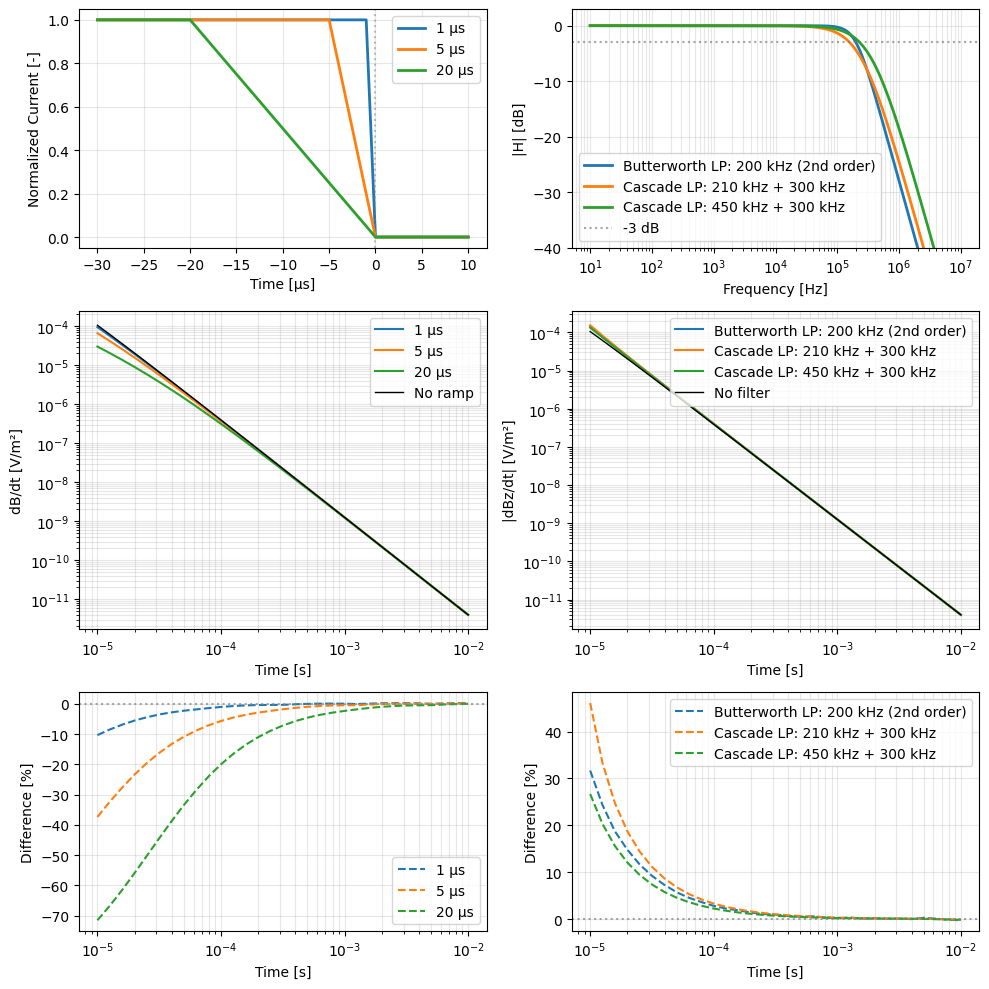

In [24]:
fig, axs = plt.subplots(3, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [1.5, 2, 1.5]})
ramp_colors = ['C0', 'C1', 'C2']

# (a) Waveform shapes
max_ramp = max(ramp_durations)
for T, c in zip(ramp_durations, ramp_colors):
    t_wf = np.array([-1.5*max_ramp, -T, 0, 0.5*max_ramp]) * 1e6
    axs[0, 0].plot(t_wf, [1, 1, 0, 0], c=c, lw=2, label=f'{T*1e6:.0f} µs')
axs[0, 0].axvline(0, color='gray', ls=':', alpha=0.5)
axs[0, 0].set(xlabel='Time [µs]', ylabel='Normalized Current [-]')
axs[0, 0].legend(); axs[0, 0].grid(True, alpha=0.3)

# (b) Convolved responses
for T, c in zip(ramp_durations, ramp_colors):
    axs[1, 0].loglog(times, np.abs(dbdt_ramp[T]), c=c, lw=1.5, label=f'{T*1e6:.0f} µs')
axs[1, 0].loglog(times, np.abs(dbdt_num_50), 'k-', lw=1, label='No ramp')
axs[1, 0].set(xlabel='Time [s]', ylabel=r'dB/dt [V/m²]')
axs[1, 0].legend(); axs[1, 0].grid(True, which='both', alpha=0.3)

# (c) Ramp-off % change vs step-off
for T, c in zip(ramp_durations, ramp_colors):
    pct = 100 * (np.abs(dbdt_ramp[T]) - np.abs(dbdt_num_50)) / np.abs(dbdt_num_50)
    axs[2, 0].semilogx(times, pct, c=c, ls='--', label=f'{T*1e6:.0f} µs')
axs[2, 0].axhline(0, color='gray', ls=':', alpha=0.7)
axs[2, 0].set(xlabel='Time [s]', ylabel='Difference [%]')
axs[2, 0].legend(); axs[2, 0].grid(True, which='both', alpha=0.3)

filt_configs = [
    ('Butterworth LP: 200 kHz (2nd order)',   butterworth_filter(f_high=200e3, order=2)),
    ('Cascade LP: 210 kHz + 300 kHz',  cascade_filter(210e3)),
    ('Cascade LP: 450 kHz + 300 kHz',  cascade_filter(450e3)),
]
filt_colors = ['C0', 'C1', 'C2']

dbdt_filtered = {}
for label, filt in filt_configs:
    dbdt_filtered[label] = fwd_circle_central([], [rho_hs], a_50, times,
                                               system_filter=filt)
    
# (d) Filter frequency response
freqs = np.logspace(1, 7, 500)
omega_arr = 2 * np.pi * freqs
for (label, filt), c in zip(filt_configs, filt_colors):
    axs[0, 1].semilogx(freqs, 20*np.log10(np.abs(filt(omega_arr))),
                        c=c, lw=2, label=label)
axs[0, 1].axhline(-3, color='gray', ls=':', alpha=0.7, label='-3 dB')
axs[0, 1].set(xlabel='Frequency [Hz]', ylabel='|H| [dB]',
               ylim=(-40, 3))
axs[0, 1].legend(); axs[0, 1].grid(True, which='both', alpha=0.3)

# (e) Filtered response
for (label, _), c in zip(filt_configs, filt_colors):
    axs[1, 1].loglog(times, np.abs(dbdt_filtered[label]), c=c, lw=1.5, label=label)
axs[1, 1].loglog(times, np.abs(dbdt_num_50), 'k-', lw=1, label='No filter')
axs[1, 1].set(xlabel='Time [s]', ylabel=r'|dBz/dt| [V/m²]')
axs[1, 1].legend(); axs[1, 1].grid(True, which='both', alpha=0.3)

# (f) Filter % change
for (label, _), c in zip(filt_configs, filt_colors):
    pct = 100 * (np.abs(dbdt_filtered[label]) - np.abs(dbdt_num_50)) / np.abs(dbdt_num_50)
    axs[2, 1].semilogx(times, pct, c=c, ls='--', label=label)
axs[2, 1].axhline(0, color='gray', ls=':', alpha=0.7)
axs[2, 1].set(xlabel='Time [s]', ylabel='Difference [%]')
axs[2, 1].legend(); axs[2, 1].grid(True, which='both', alpha=0.3)

fig.tight_layout()

add_panel_labels(axs, n_cols=2, y_shift=[0.03, 0.03, 0.03], 
                 x_shift=[0.03, 0.03, 0.03])

### Analytical Half-Space Solutions

Validation of a numerical forward model requires comparison against a known exact result. The simplest such case is a homogeneous half-space: the entire earth has a single resistivity $\rho$, and closed-form solutions for $\partial B_z / \partial t$ exist. Ward & Hohmann (1988) — Chapter 4 of Nabighian (ed.), *EM Methods in Applied Geophysics*, SEG — derive these expressions directly from the layered-earth Green's function in the limit of a single half-space.

Agreement between the numerical and analytical results across many decades of time confirms that the DLF filters, the Wait recursion, and the Fourier transform are all implemented correctly.

**Central loop** (Ward & Hohmann, 1988, eq. 4.69a):

$$\frac{\partial B_z}{\partial t} = \frac{-I}{\sigma a^3}\left[3\,\text{erf}(\theta a) - \frac{2}{\sqrt{\pi}}\theta a\,(3 + 2\theta^2 a^2)\,e^{-\theta^2 a^2}\right]$$

**Offset VMD** (Ward & Hohmann, 1988, eq. 4.97, time-differentiated):

$$\frac{\partial B_z}{\partial t} = \frac{\mu_0 M}{8\pi r^3 t}\left[\frac{9}{u^2}\text{erf}(u) - \frac{1}{\sqrt{\pi}}\left(\frac{18}{u}+12u+8u^3\right)e^{-u^2}\right]$$

where $\theta = \sqrt{\mu_0\sigma/(4t)}$, $u = \theta r$, and $M = I\pi a^2$.


In [ ]:
def halfspace_dbdt_analytic(resistivity, tx_radius, times, current=1.0):
    """Analytical dBz/dt at centre of a loop on a homogeneous half-space.
    Ward & Hohmann (1988), eq 4.69a.  Returns V/m^2."""
    times = np.asarray(times, dtype=float)
    sigma = 1.0 / resistivity
    a = float(tx_radius)

    theta = np.sqrt(MU0 * sigma / (4.0 * times))
    theta_a = theta * a

    dbdt = (-current / (sigma * a**3)) * (
        3.0 * erf(theta_a)
        - (2.0 / np.sqrt(np.pi)) * theta_a * (3.0 + 2.0 * theta_a**2)
        * np.exp(-theta_a**2)
    )
    return dbdt

def halfspace_dbdt_offset_analytic(resistivity, tx_radius, rx_offset, times,
                                   current=1.0):
    """Analytical dBz/dt at offset r from a VMD on a homogeneous half-space.
    Ward & Hohmann (1988), eq 4.97 differentiated w.r.t. time.
    Valid in the far field (r >> a).  Returns V/m^2 (T/s)."""
    times = np.asarray(times, dtype=float)
    sigma = 1.0 / resistivity
    r = float(rx_offset)
    M = current * np.pi * float(tx_radius)**2   # Tx dipole moment

    theta = np.sqrt(MU0 * sigma / (4.0 * times))
    u = theta * r                       # u = theta * r

    dbdt = (MU0 * M / (8.0 * np.pi * r**3 * times)) * (
        (9.0 / u**2) * erf(u)
        - (1.0 / np.sqrt(np.pi)) * (18.0 / u + 12.0 * u + 8.0 * u**3)
        * np.exp(-u**2)
    )
    return dbdt

### Comparison with Analytical Solutions (Ward & Hohmann, 1988)

For a homogeneous half-space, closed-form expressions for $\partial B_z/\partial t$ are available.  Comparing the numerical DLF result with the analytical formula across many decades of time confirms that the Wait recursion, Hankel filter, and Fourier filter are all implemented correctly.


In [ ]:
# Central-loop validation for large Tx loop
dbdt_ana_200 = halfspace_dbdt_analytic(rho_hs, a_200, times)
dbdt_num_200 = fwd_circle_central([], [rho_hs], a_200, times)
rel_err_200 = np.abs((dbdt_num_200 - dbdt_ana_200) / dbdt_ana_200) * 100

# Central-loop validation for smaller Tx loop
dbdt_ana_50 = halfspace_dbdt_analytic(rho_hs, a_50, times)
dbdt_num_50 = fwd_circle_central([], [rho_hs], a_50, times)
rel_err_50 = np.abs((dbdt_num_50 - dbdt_ana_50) / dbdt_ana_50) * 100

# Offset validation — use small Tx loop so r/a >> 1 (VMD approx valid)
r = 10  # offset [m] → r/a = 50
dbdt_offset_num = fwd_circle_offset([], [rho_hs], a_3, r, times)
dbdt_offset_ana = halfspace_dbdt_offset_analytic(rho_hs, a_3, r, times)
rel_err_offset = np.abs((dbdt_offset_num - dbdt_offset_ana) / dbdt_offset_ana) * 100

print("=== Test 1a: Central-loop half-space validation for large Tx loop ===")
print(f"  rho = {rho_hs} Ohm.m, a = {a_200:.2f} m")
print(f"  Max  relative error: {rel_err_200.max():.4f} %")
print(f"  Mean relative error: {rel_err_200.mean():.4f} %")
print(f"\n=== Test 1b: Central-loop half-space validation for smaller Tx loop ===") 
print(f"  rho = {rho_hs} Ohm.m, a = {a_50:.2f} m")
print(f"  Max  relative error: {rel_err_50.max():.4f} %")
print(f"  Mean relative error: {rel_err_50.mean():.4f} %")
print(f"\n=== Test 1c: Offset-loop half-space validation ===")
print(f"  rho = {rho_hs} Ohm.m, a = {a_3:.2f} m, offset r = {r} m")
print(f"  Max  relative error: {rel_err_offset.max():.4f} %")
print(f"  Mean relative error: {rel_err_offset.mean():.4f} %")
print(f"  (VMD approx valid for r/a >> 1; r/a = {r/a_3:.1f})")

=== Test 1a: Central-loop half-space validation for large Tx loop ===
  rho = 100.0 Ohm.m, a = 112.84 m
  Max  relative error: 0.0001 %
  Mean relative error: 0.0000 %

=== Test 1b: Central-loop half-space validation for smaller Tx loop ===
  rho = 100.0 Ohm.m, a = 28.21 m
  Max  relative error: 0.0391 %
  Mean relative error: 0.0024 %

=== Test 1c: Offset-loop half-space validation ===
  rho = 100.0 Ohm.m, a = 1.69 m, offset r = 10 m
  Max  relative error: 0.0994 %
  Mean relative error: 0.0369 %
  (VMD approx valid for r/a >> 1; r/a = 5.9)


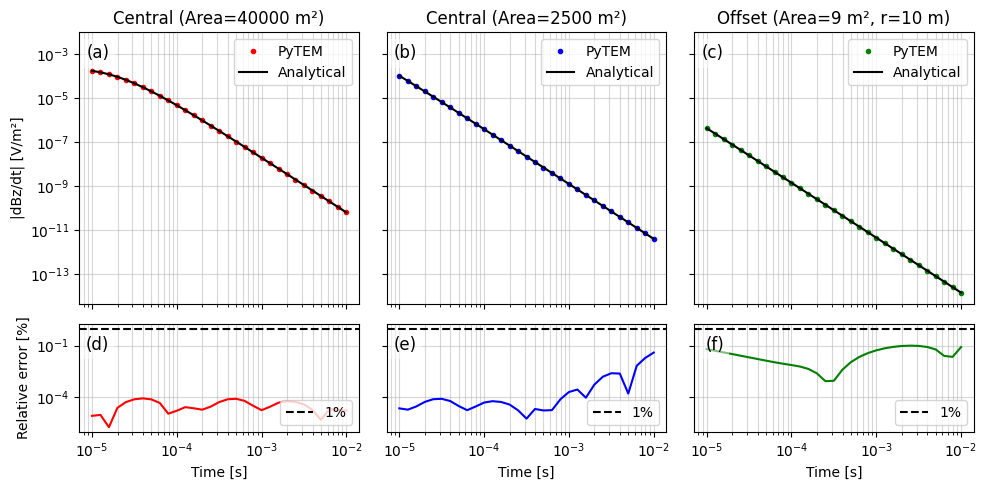

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey='row',
                        gridspec_kw={'height_ratios': [2.5, 1]})

# Response panels
cases = [
    (dbdt_num_200, dbdt_ana_200, 'r.', f'Central (Area={A_200:.0f} m²)'),
    (dbdt_num_50,  dbdt_ana_50,  'b.', f'Central (Area={A_50:.0f} m²)'),
    (dbdt_offset_num, dbdt_offset_ana, 'g.', f'Offset (Area={A_3:.0f} m², r={r} m)'),
]
errors = [rel_err_200, rel_err_50, rel_err_offset]
colors = ['r', 'b', 'g']

for j, (num, ana, marker, title) in enumerate(cases):
    axs[0, j].loglog(times, np.abs(num), marker, label='PyTEM')
    axs[0, j].loglog(times, np.abs(ana), 'k-', label='Analytical')
    axs[0, j].set_title(title)
    axs[0, j].legend()
    axs[0, j].grid(True, which='both', alpha=0.5)

for j in range(3):
    axs[1, j].loglog(times, errors[j], f'{colors[j]}-')
    axs[1, j].axhline(1, color='k', ls='--', label='1%')
    axs[1, j].legend(loc='lower right')
    axs[1, j].grid(True, which='both', alpha=0.5)
    axs[1, j].set_xlabel('Time [s]')

axs[0, 0].set_ylabel('|dBz/dt| [V/m²]')
axs[1, 0].set_ylabel('Relative error [%]')
axs[0, 0].set_ylim(None, 1e-2)

fig.tight_layout()

def add_panel_labels(axs, n_cols=3, x_shift=[0.03], y_shift=[0.06]):
    n_rows = len(axs)
    if len(x_shift) == 1:
        x_shift = x_shift * n_rows
    if len(y_shift) == 1:
        y_shift = y_shift * n_rows
    letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    x0s = [ax.get_position().x0 for ax in axs[0]]   # one per column
    y1s = [axs[r, 0].get_position().y1 for r in range(n_rows)]  # one per row
    for i, ax in enumerate(axs.flat):
        row, col = divmod(i, n_cols)
        fig.text(x0s[col] + x_shift[row], y1s[row] - y_shift[row], letters[i],
                fontsize=12, va='bottom', ha='right', 
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        
add_panel_labels(axs)

### Comparison with AarhusInv

AarhusInv (Auken *et al.*, 2015) is a widely used commercial TEM inversion package.  Here pyTEM forward responses for two three-layer models (Low-High-Low and High-Low-High resistivity sequences) are compared with AarhusInv reference values for both central (50 × 50 m) and offset (3 × 3 m, receiver 10 m away) square-loop configurations.


In [ ]:
# Model 1: low-high-low (10 / 100 / 10 Ohm.m, thicknesses 30, 20 m)
times = np.logspace(-5, -2, 31)
th1 = [30.0, 20.0]
rho1 = [10.0, 100.0, 10.0]
pytem_lhl_central = fwd_square_central(
    th1, rho1, L_50, times, n_quad=5
)
pytem_lhl_offset = fwd_square_offset(
    th1, rho1, L_3, 10.0, 0.0, times, n_quad=11
)

# Reference: AarhusInv (same 31 gate times)
aarhus_inv_lhl_central = np.array([
    7.749263e-04, 5.871443e-04, 4.271254e-04, 2.941576e-04,
    1.987840e-04, 1.300814e-04, 8.290166e-05, 5.142938e-05,
    3.088973e-05, 1.800577e-05, 1.016799e-05, 5.596638e-06,
    3.068655e-06, 1.627900e-06, 8.845018e-07, 4.805502e-07,
    2.641654e-07, 1.474779e-07, 8.327249e-08, 4.758555e-08,
    2.731165e-08, 1.571936e-08, 9.167189e-09, 5.228992e-09,
    3.042238e-09, 1.754475e-09, 1.009169e-09, 5.802100e-10,
    3.325352e-10, 1.906650e-10, 1.088946e-10])

aarhus_inv_lhl_offset = np.array([
    8.909462e-06, 5.534735e-06, 3.400043e-06, 2.015686e-06,
    1.206456e-06, 7.121532e-07, 4.165131e-07, 2.407902e-07,
    1.365293e-07, 7.600484e-08, 4.138204e-08, 2.213696e-08,
    1.188021e-08, 6.196162e-09, 3.325720e-09, 1.790114e-09,
    9.771045e-10, 5.425529e-10, 3.050211e-10, 1.737058e-10,
    9.941518e-11, 5.708730e-11, 3.323015e-11, 1.892443e-11,
    1.099644e-11, 6.335048e-12, 3.640742e-12, 2.091701e-12,
    1.198096e-12, 6.866033e-13, 3.919703e-13])

# Model 2: high-low-high (100 / 10 / 100 Ohm.m, same geometry)
th2 = [30.0, 20.0]
rho2 = [100.0, 10.0, 100.0]
pytem_hlh_central = fwd_square_central(
    th2, rho2, L_50, times, n_quad=5,
)
pytem_hlh_offset = fwd_square_offset(
    th2, rho2, L_3, 10.0, 0.0, times, n_quad=11,
)

aarhus_inv_hlh_central = np.array([
    8.272315e-05, 5.190274e-05, 3.479861e-05, 2.416104e-05,
    1.762117e-05, 1.301000e-05, 9.569980e-06, 6.896801e-06,
    4.807463e-06, 3.231898e-06, 2.085133e-06, 1.292234e-06,
    7.797680e-07, 4.444820e-07, 2.505580e-07, 1.362780e-07,
    7.227618e-08, 3.765000e-08, 1.929029e-08, 9.805497e-09,
    4.939895e-09, 2.478716e-09, 1.262451e-09, 6.272540e-10,
    3.213085e-10, 1.641116e-10, 8.432066e-11, 4.371778e-11,
    2.279963e-11, 1.200644e-11, 6.349225e-12])

aarhus_inv_hlh_offset = np.array([
    3.640381e-07, 2.263633e-07, 1.504536e-07, 1.032424e-07,
    7.422265e-08, 5.386947e-08, 3.889692e-08, 2.751781e-08,
    1.884899e-08, 1.247316e-08, 7.936371e-09, 4.860343e-09,
    2.904472e-09, 1.641974e-09, 9.197265e-10, 4.977077e-10,
    2.629333e-10, 1.365618e-10, 6.981305e-11, 3.542850e-11,
    1.782658e-11, 8.936757e-12, 4.548541e-12, 2.258713e-12,
    1.156518e-12, 5.904800e-13, 3.032834e-13, 1.571915e-13,
    8.195089e-14, 4.314070e-14, 2.280462e-14])

# Percentage differences vs AarhusInv
pct_aarhus_lhl_central = 100 * np.abs(np.abs(pytem_lhl_central) - np.abs(aarhus_inv_lhl_central)) / np.maximum(np.abs(pytem_lhl_central), 1e-30)
pct_aarhus_lhl_offset = 100 * np.abs(np.abs(pytem_lhl_offset) - np.abs(aarhus_inv_lhl_offset)) / np.maximum(np.abs(pytem_lhl_offset), 1e-30)
pct_aarhus_hlh_central = 100 * np.abs(np.abs(pytem_hlh_central) - np.abs(aarhus_inv_hlh_central)) / np.maximum(np.abs(pytem_hlh_central), 1e-30)
pct_aarhus_hlh_offset = 100 * np.abs(np.abs(pytem_hlh_offset) - np.abs(aarhus_inv_hlh_offset)) / np.maximum(np.abs(pytem_hlh_offset), 1e-30)

print(f"LHL central: max diff vs AarhusInv = {pct_aarhus_lhl_central.max():.2f}%")
print(f"LHL offset : max diff vs AarhusInv = {pct_aarhus_lhl_offset.max():.2f}%")
print(f"HLH central: max diff vs AarhusInv = {pct_aarhus_hlh_central.max():.2f}%")
print(f"HLH offset : max diff vs AarhusInv = {pct_aarhus_hlh_offset.max():.2f}%")

LHL central: max diff vs AarhusInv = 0.84%
LHL offset : max diff vs AarhusInv = 0.85%
HLH central: max diff vs AarhusInv = 0.90%
HLH offset : max diff vs AarhusInv = 0.84%


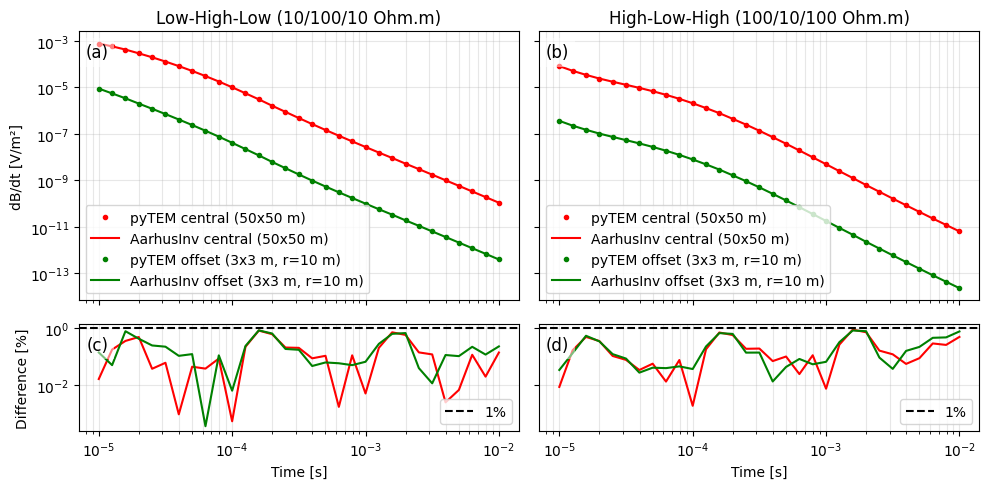

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey='row',
                        gridspec_kw={'height_ratios': [2.5, 1]})

# LHL model: central and offset responses
axs[0, 0].loglog(times, np.abs(pytem_lhl_central), 'r.', label='PyTEM central (50x50 m)')
axs[0, 0].loglog(times, np.abs(aarhus_inv_lhl_central), 'r-', ms=3, label='AarhusInv central (50x50 m)')
axs[0, 0].loglog(times, np.abs(pytem_lhl_offset), 'g.', label='PyTEM offset (3x3 m, r=10 m)')
axs[0, 0].loglog(times, np.abs(aarhus_inv_lhl_offset), 'g-', ms=3, label='AarhusInv offset (3x3 m, r=10 m)')
axs[0, 0].set_title('Low-High-Low (10/100/10 Ohm.m)')
axs[0, 0].set_ylabel(r'dB/dt [V/m²]')
axs[0, 0].legend()
axs[0, 0].grid(True, which='both', alpha=0.3)

axs[1, 0].loglog(times, pct_aarhus_lhl_central, 'r-')
axs[1, 0].loglog(times, pct_aarhus_lhl_offset, 'g-')
axs[1, 0].axhline(1, color='k', ls='--', label='1%')
axs[1, 0].set_ylabel('Difference [%]')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].legend(loc='lower right')
axs[1, 0].grid(True, which='both', alpha=0.3)

# HLH model: central and offset responses
axs[0, 1].loglog(times, np.abs(pytem_hlh_central), 'r.', label='PyTEM central (50x50 m)')
axs[0, 1].loglog(times, np.abs(aarhus_inv_hlh_central), 'r-', ms=3, label='AarhusInv central (50x50 m)')
axs[0, 1].loglog(times, np.abs(pytem_hlh_offset), 'g.', label='PyTEM offset (3x3 m, r=10 m)')
axs[0, 1].loglog(times, np.abs(aarhus_inv_hlh_offset), 'g-', ms=3, label='AarhusInv offset (3x3 m, r=10 m)')
axs[0, 1].set_title('High-Low-High (100/10/100 Ohm.m)')
axs[0, 1].legend()
axs[0, 1].grid(True, which='both', alpha=0.3)

axs[1, 1].loglog(times, pct_aarhus_hlh_central, 'r-')
axs[1, 1].loglog(times, pct_aarhus_hlh_offset, 'g-')
axs[1, 1].axhline(1, color='k', ls='--', label='1%')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 1].grid(True, which='both', alpha=0.3)
axs[1, 1].legend(loc='lower right')

fig.tight_layout()
add_panel_labels(axs, n_cols=2)

---

## Bonus: Square Loop vs Circular Equivalent-Area Approximation

> **Note:** This section is **not covered in the paper** but is an important practical consideration.  When the exact square-loop kernel is too expensive (e.g. for large-scale inversion), the loop is often approximated by a circular loop with the same area: $a_{eff} = L/\sqrt{\pi}$.  The comparison below quantifies the error introduced by this approximation for the three standard survey geometries.


### Test 2 — Square loop vs circular equivalent

Compare the central square-loop response (area integral) against the circular-loop response using the equivalent radius $a_{eff} = L/\sqrt{\pi}$ (equal area). The difference quantifies the geometry effect between square and circular loop shapes.

In [ ]:
# --- Case 1: 200x200 central ---
L_200 = 200.0
a_200 = np.sqrt((L_200**2) / np.pi)
dbdt_sq_200 = fwd_square_central([], [rho_hs], L_200, times, n_quad=7)
dbdt_ci_200 = fwd_circle_central([], [rho_hs], a_200, times)
rel_200 = 100 * np.abs(dbdt_sq_200 - dbdt_ci_200) / np.maximum(np.abs(dbdt_sq_200), 1e-30)

# --- Case 2: 50x50 central ---
L_50 = 50.0
a_50 = np.sqrt((L_50**2) / np.pi)
dbdt_sq_50 = fwd_square_central([], [rho_hs], L_50, times, n_quad=9)
dbdt_ci_50 = fwd_circle_central([], [rho_hs], a_50, times)
rel_50 = 100 * np.abs(dbdt_sq_50 - dbdt_ci_50) / np.maximum(np.abs(dbdt_sq_50), 1e-30)

# --- Case 3: 3x3 offset ---
L_3 = 3.0
a_3 = np.sqrt((L_3**2) / np.pi)
rx_offset = 10.0
rx_x, rx_y = rx_offset, 0.0
dbdt_sq_3_off = fwd_square_offset([], [rho_hs], L_3, rx_x, rx_y, times, n_quad=13)
dbdt_ci_3_off = fwd_circle_offset([], [rho_hs], a_3, rx_offset, times)
rel_3_off = 100 * np.abs(dbdt_sq_3_off - dbdt_ci_3_off) / np.maximum(np.abs(dbdt_sq_3_off), 1e-30)

print("=== Comparison summary ===")
print(f"200x200 central: max Δ = {rel_200.max():.3f}% | mean Δ = {rel_200.mean():.3f}%")
print(f"50x50 central  : max Δ = {rel_50.max():.3f}% | mean Δ = {rel_50.mean():.3f}%")
print(f"3x3 offset     : max Δ = {rel_3_off.max():.3f}% | mean Δ = {rel_3_off.mean():.3f}% (r={rx_offset} m)")

=== Comparison summary ===
200x200 central: max Δ = 1.972% | mean Δ = 0.660%
50x50 central  : max Δ = 0.740% | mean Δ = 0.123%
3x3 offset     : max Δ = 0.003% | mean Δ = 0.001% (r=10.0 m)


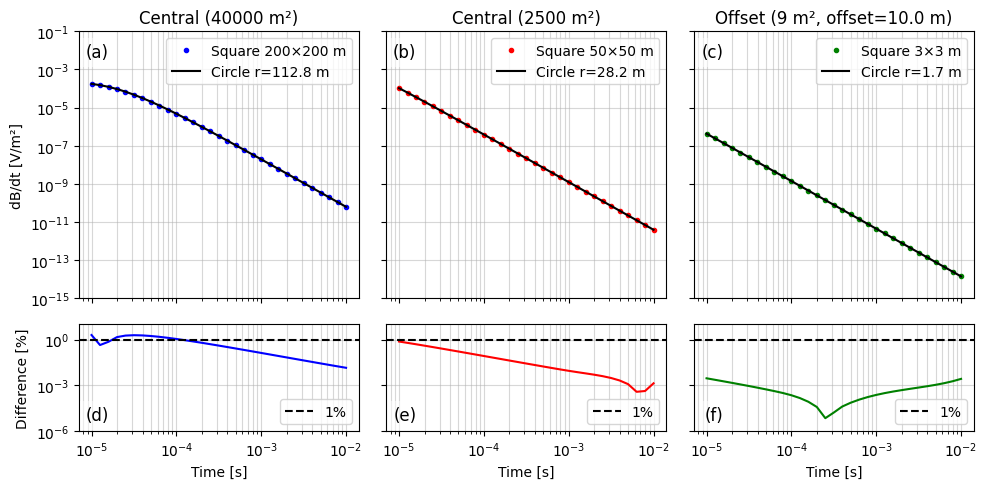

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey='row',
                        gridspec_kw={'height_ratios': [2.5, 1]})

cases = [
    (dbdt_sq_200, dbdt_ci_200, rel_200, 'b', f'Square {L_200:.0f}×{L_200:.0f} m', f'Circle r={a_200:.1f} m', f'Central ({L_200**2:.0f} m²)'),
    (dbdt_sq_50,  dbdt_ci_50,  rel_50,  'r', f'Square {L_50:.0f}×{L_50:.0f} m', f'Circle r={a_50:.1f} m',  f'Central ({L_50**2:.0f} m²)'),
    (dbdt_sq_3_off, dbdt_ci_3_off, rel_3_off, 'g', f'Square {L_3:.0f}×{L_3:.0f} m', f'Circle r={a_3:.1f} m', f'Offset ({L_3**2:.0f} m², offset={rx_offset} m)'),
]

for j, (sq, ref, rel, c, sq_lbl, ref_lbl, title) in enumerate(cases):
    axs[0, j].loglog(times, np.abs(sq), f'{c}.', lw=2, label=sq_lbl)
    axs[0, j].loglog(times, np.abs(ref), 'k-', lw=1.5, label=ref_lbl)
    axs[0, j].set_title(title)
    axs[0, j].legend()
    axs[0, j].grid(True, which='both', alpha=0.5)

    axs[1, j].loglog(times, rel, f'{c}-')
    axs[1, j].axhline(1, color='k', ls='--', label='1%')
    axs[1, j].set_xlabel('Time [s]')
    axs[1, j].legend(loc='lower right')
    axs[1, j].grid(True, which='both', alpha=0.5)

axs[0, 0].set_ylabel(r'dB/dt [V/m²]')
axs[1, 0].set_ylabel('Difference [%]')
axs[1, 1].set_ylim(1e-6, 10)
axs[0, 0].set_ylim(1e-15, 1e-1)

fig.tight_layout()

add_panel_labels(axs, y_shift=[0.06, 0.2])